In [1]:
from torch.utils.data import Dataset, DataLoader
import json

class DuReaderQG(Dataset):
    def __init__(self, data_file):
        super().__init__()
        self.data = self.load_data(data_file)

    def load_data(self, data_file):
        data_res = {}
        with open(data_file, "rt") as f:
            for index, line in enumerate(f):
                sample = json.loads(line.strip())
                data_res[index] = sample

        return data_res
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
# train_data = DuReaderQG("data/DuReaderQG/train.json")
# valid_data = DuReaderQG("data/DuReaderQG/dev.json")

# print(train_data.__getitem__(0))

In [2]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("./model/langboat/mengzi-t5-base")

def collate_fn(batch):
    
    questions = [item['question'] for item in batch]
    contexts = [item['context'] for item in batch]
    answers = [item['answer'] for item in batch]

    # 批量编码输入
    inputs = tokenizer(
        [f"question: {q} context: {c}" for q, c in zip(questions, contexts)],
        padding=True,          # 动态补齐到本 Batch 最长
        truncation=True,
        max_length=1024,  
        return_tensors="pt"
    )
    
    # 批量编码标签
    labels = tokenizer(
        answers,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    # T5 规范：将 padding token 的标签设置为 -100，计算 Loss 时会自动忽略？？？
    labels[labels == tokenizer.pad_token_id] = -100

    return {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "labels": labels["input_ids"]
    }


In [3]:
import os
import torch

def save_full_checkpoint(output_dir, model, tokenizer, optimizer, scheduler, epoch, global_step, best_bleu4):
    """HF 权重 + tokenizer + 优化器/调度器/RNG 等完整训练状态（固定目录覆盖保存）。"""
    os.makedirs(output_dir, exist_ok=True)
    # 原始mengzi-t5-base中shared和lm_head 是两套独立权重
    model.config.tie_word_embeddings = False
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    state = {
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
        "best_bleu4": float(best_bleu4),
        "torch_rng_state": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["cuda_rng_state_all"] = torch.cuda.get_rng_state_all()
    torch.save(state, os.path.join(output_dir, "training_state.pt"))

In [4]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm
import torch

def valid_loop(dataloader, model, epoch, epochs, device):
  
    all_preds = []   # 存储所有预测答案的字符列表
    all_refs = []    # 存储所有标准答案的字符列表（嵌套结构）
    total_loss = 0

    loop = tqdm(dataloader, leave = True)
    loop.set_description(f"Testing Epoch [{epoch+1}/{epochs}]")

    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(loop):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # 模型生成
            outputs = model.generate(input_ids = input_ids,
                                    attention_mask = attention_mask,
                                    max_length=64)
            # 解码为字符串文本
            pred_texts = tokenizer.batch_decode(outputs, skip_special_tokens=True)

            # 处理标准答案 (Labels)
            # 注意：需排除掉为了 padding 而设置的 -100
            label_ids = batch["labels"].cpu().numpy()
            label_ids = [[t for t in label if t != -100] for label in label_ids]
            ref_texts = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

            # --- 核心步骤：转换为 corpus_bleu 要求的格式 ---
            for pred, ref in zip(pred_texts, ref_texts):
                # 将字符串转为字符列表，例如 "12月" -> ["1", "2", "月"]
                pred_list = list(pred)
                ref_list = [list(ref)] # 每一个参考答案必须再包一层列表
                
                all_preds.append(pred_list)
                all_refs.append(ref_list)

            #计算 Loss (用于画曲线)
            outputs_for_loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs_for_loss.loss.item()

            avg_loss = total_loss / (batch_idx + 1)
            loop.set_postfix(avg_loss=f"{avg_loss:.4f}")

        # 2. 循环结束后，统一计算各个维度的 BLEU
        smoothing = SmoothingFunction().method1 #  使用平滑函数防止n-gram为0时分数为0
        
        # 定义不同维度的权重
        weights_list = {
            "BLEU-1": (1, 0, 0, 0),
            "BLEU-2": (0.5, 0.5, 0, 0),
            "BLEU-3": (0.33, 0.33, 0.33, 0),
            "BLEU-4": (0.25, 0.25, 0.25, 0.25)
        }

        bleu_res = {}
        for name, weights in weights_list.items():
            score = corpus_bleu(all_refs, all_preds, weights=weights, smoothing_function=smoothing)
            bleu_res[name] = score

        return avg_loss, bleu_res


In [5]:

def train_loop(train_loader,valid_loader, model, tokenizer,optimizer, lr_scheduler, epoch, epochs, device, writer, global_step_start,
    best_score_ref,
    best_dir,
    validation_loss_res,
    eval_step,
    train_log_step):

    # 带有动态进度条的可迭代对象
    loop = tqdm(train_loader, leave = True)
    loop.set_description(f"Training Epoch [{epoch+1}/{epochs}]")
    total_loss = 0
    step = global_step_start

    model.train()
    for batch_idx, batch in enumerate(loop):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) 
 
        output = model(input_ids = input_ids,
                     attention_mask = attention_mask,
                     labels = labels)
        loss = output.loss  # 当前batch的平均loss
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        step += 1
        total_loss += loss.item()
        avg_loss = total_loss / (batch_idx + 1)

        loop.set_postfix(avg_loss=f"{avg_loss:.4f}")

        if step % train_log_step == 0:
            writer.add_scalar("Loss/train", loss.item(), step)

        if step % eval_step == 0:
            val_loss, bleu_res = valid_loop(valid_loader, model, epoch, epochs, device)
            print("=" * 30)
            print(f"验证 global_step={step} | epoch={epoch + 1}/{epochs} | val_loss={val_loss:.4f}")
            for name, score in bleu_res.items():
                print(f"  {name}: {score:.4f}")
            print("=" * 30)

            validation_loss_res.append(val_loss)
            writer.add_scalar("Loss/valid", val_loss, step)

            if bleu_res["BLEU-4"] > best_score_ref[0]:
                best_score_ref[0] = bleu_res["BLEU-4"]
                save_full_checkpoint(
                    best_dir, model, tokenizer, optimizer, lr_scheduler,
                    epoch + 1, step, best_score_ref[0],
                )
            model.train()
    
    return avg_loss, step # 返回本 epoch 结束时的全局 step


In [6]:
from torch.optim import AdamW
from transformers import get_scheduler
from torch.utils.tensorboard import SummaryWriter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

BEST_DIR = "./checkpoints/best_model"
LATEST_DIR = "./checkpoints/latest_epoch"

training_loss_res, validation_loss_res = [],[]
train_dataset = DuReaderQG("data/DuReaderQG/train.json")
valid_data = DuReaderQG("data/DuReaderQG/dev.json")
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle = True, collate_fn = collate_fn)
valid_loader = DataLoader(valid_data, batch_size = 16, shuffle = False, collate_fn = collate_fn)

model = T5ForConditionalGeneration.from_pretrained("./model/langboat/mengzi-t5-base").to(device)
# 3. 恢复训练时（说明）
# 从 best_model 或 latest 目录加载时：
# T5ForConditionalGeneration.from_pretrained(目录)、T5Tokenizer.from_pretrained(目录)
# torch.load(目录/training_state.pt)，恢复 optimizer、lr_scheduler、epoch、global_step 等。

epochs = 3
lr = 3e-5
optimizer = AdamW(model.parameters(), lr = lr, weight_decay = 0.01)
lr_scheduler = get_scheduler(
    name = "linear",
    optimizer = optimizer,
    num_warmup_steps=0,
    num_training_steps = epochs * len(train_loader)
)

best_score_ref = [0.0]
writer = SummaryWriter(log_dir="runs/dureader_qg")
global_step = 0

for epoch in range(epochs):
    training_loss, global_step = train_loop(train_loader, valid_loader, model, tokenizer, optimizer, lr_scheduler, epoch, epochs, device, writer, global_step,
        best_score_ref,
        BEST_DIR,
        validation_loss_res,
        eval_step = 100,
        train_log_step= 20)
    save_full_checkpoint(
        LATEST_DIR,
        model,
        tokenizer,
        optimizer,
        lr_scheduler,
        epoch + 1,
        global_step,
        best_score_ref[0],
    )

    
    # training_loss_res.append(training_loss)
    # validation_loss, bleu_res = valid_loop(valid_loader, model, epoch, epochs, device)
    # validation_loss_res.append(validation_loss)
    # print("="*30)
    # print(f"模型评估-Epoch {epoch + 1}:")
    # for name, score in bleu_res.items():
    #     print(f"{name}: {score:.4f}")
    # print("="*30) 

    # # 保存模型
    # if bleu_res["BLEU-4"] > best_score:
    #     best_score = bleu_res["BLEU-4"]
    #     output_dir = f"./checkpoints/epoch_{epoch+1}_valid_bleu_4:{best_score:.4f}_model"
    #     model.save_pretrained(output_dir)
    #     tokenizer.save_pretrained(output_dir)

writer.close()

print("=======Done!=======")


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


  0%|          | 0/1815 [00:00<?, ?it/s]

  0%|          | 0/62 [00:00<?, ?it/s]

验证 global_step=100 | epoch=1/3 | val_loss=0.6899
  BLEU-1: 0.3894
  BLEU-2: 0.3558
  BLEU-3: 0.3272
  BLEU-4: 0.2926


...

验证 global_step=5300 | epoch=3/3 | val_loss=0.4209
  BLEU-1: 0.7341
  BLEU-2: 0.7109
  BLEU-3: 0.6860
  BLEU-4: 0.6572


  0%|          | 0/62 [00:00<?, ?it/s]

验证 global_step=5400 | epoch=3/3 | val_loss=0.4195
  BLEU-1: 0.7339
  BLEU-2: 0.7112
  BLEU-3: 0.6871
  BLEU-4: 0.6591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=======Done!=======


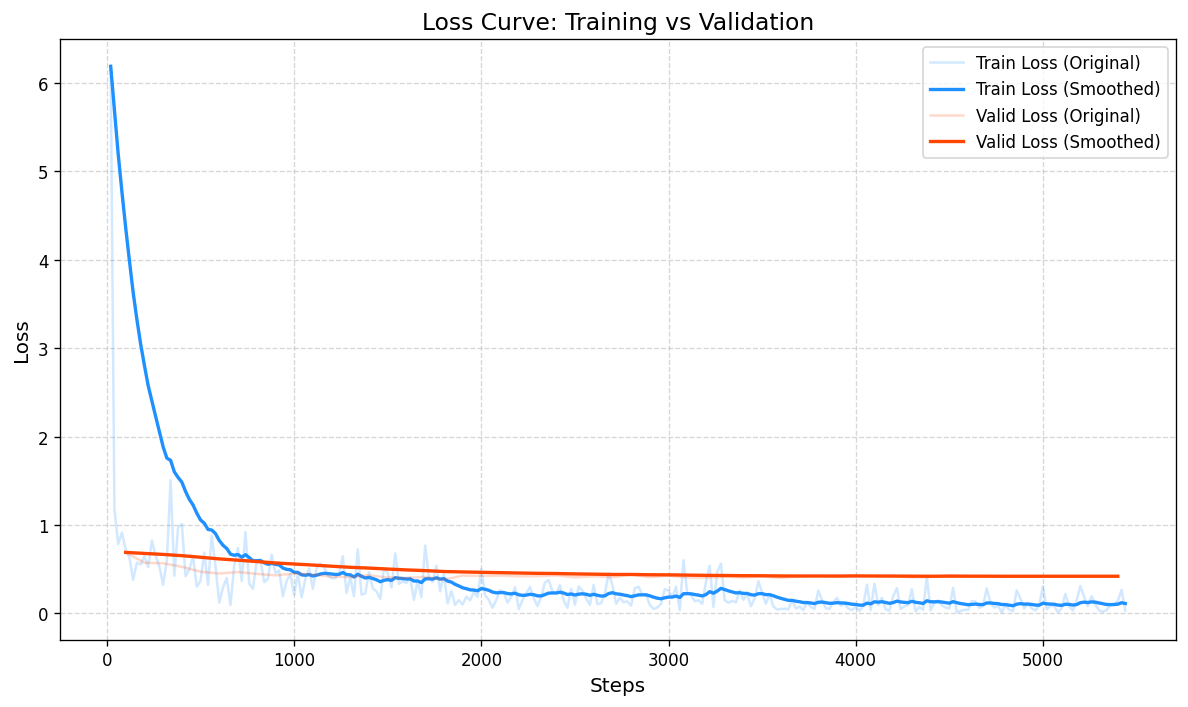

In [7]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def get_loss_data(log_dir, tag_name):
    """从 TensorBoard 日志中提取数据"""
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    if tag_name not in ea.Tags()['scalars']:
        return None, None
    events = ea.Scalars(tag_name)
    return [e.step for e in events], [e.value for e in events]

def smooth_curve(values, weight=0.85):
    """指数移动平均平滑"""
    last = values[0]
    smoothed = []
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# --- 1. 配置参数 ---
log_path = './runs/dureader_qg'  # 训练日志路径
train_tag = 'Loss/train'        # 根据你 TensorBoard 里的实际名字修改
valid_tag = 'Loss/valid'        # 根据你 TensorBoard 里的实际名字修改
smooth_weight = 0.9             # 平滑系数，越接近 1 越平滑

# --- 2. 提取数据 ---
t_steps, t_values = get_loss_data(log_path, train_tag)
v_steps, v_values = get_loss_data(log_path, valid_tag)

if t_values is None or v_values is None:
    print("错误：未找到指定的 Tag，请检查 train_tag 和 valid_tag 是否正确")
else:
    # --- 3. 计算平滑数据 ---
    t_smoothed = smooth_curve(t_values, weight=smooth_weight)
    v_smoothed = smooth_curve(v_values, weight=smooth_weight)

    # --- 4. 绘图 ---
    plt.figure(figsize=(10, 6), dpi=120)
    
    # 绘制训练集：原始线(浅色) + 平滑线(深色)
    plt.plot(t_steps, t_values, color='dodgerblue', alpha=0.2, label='Train Loss (Original)')
    plt.plot(t_steps, t_smoothed, color='dodgerblue', linewidth=2, label='Train Loss (Smoothed)')

    # 绘制验证集：原始线(浅色) + 平滑线(深色)
    plt.plot(v_steps, v_values, color='orangered', alpha=0.2, label='Valid Loss (Original)')
    plt.plot(v_steps, v_smoothed, color='orangered', linewidth=2, label='Valid Loss (Smoothed)')

    # --- 5. 美化图表 ---
    plt.title('Loss Curve: Training vs Validation', fontsize=14)
    plt.xlabel('Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', frameon=True)
    
    # 限制 Y 轴范围（可选，防止异常值导致曲线被压缩）
    # plt.ylim(0, max(max(t_smoothed), max(v_smoothed)) * 1.2)

    plt.tight_layout()
    plt.savefig('./loss_curve.png')
    plt.show()

In [8]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration, AutoTokenizer, AutoModel 

def predict_answer(context, query, model_path, device):
    """
    给定 context 和 query，生成对应答案
    :param context: 参考文章内容
    :param query: 提问的问题
    :param model_path: 训练好的模型权重路径
    :return: 模型生成的答案字符串
    """
    # 1. 自动选择运行设备 (GPU 或 CPU)
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 2. 加载训练好的 Tokenizer 和模型
    # 注意：这里加载的是你训练并保存后的 checkpoint 文件夹

    # T5Tokenizer.from_pretrained 时，它会专门去寻找 spiece.model 文件。如果找不到，或者文件夹里的 tokenizer_config.json 指向了它无法解析的格式，就会抛出 TypeError
    # tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained("./model/langboat/mengzi-t5-base")
    # AutoModel 只加载模型的核心网络层（即 Encoder 和 Decoder 的 Backbones），它不包含用于文本生成的 LM Head（语言模型输出头）。没有这个输出头，模型就不知道怎么把向量变回文字，自然也就没有 .generate() 方法。
    model = T5ForConditionalGeneration.from_pretrained(model_path).to(device)
    
    # 将模型设置为评估模式（关闭 Dropout 等）
    model.eval()

    # 3. 按照训练时的格式拼接输入文本
    # T5 格式：question: [问题] context: [文章]
    input_text = f"question: {query} context: {context}"

    # 4. 文本编码
    # padding 和 truncation 确保长度符合模型要求
    inputs = tokenizer(
        input_text,
        padding=True,
        truncation=True,
        max_length=1024,
        return_tensors="pt"
    )

    # print(f"inputs shape:{inputs.size()}")
    # 5. 模型生成 (推理)
    # 使用 Beam Search (束搜索) 提高生成质量，num_beams=4 是常用配置
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"].to(device),
            attention_mask=inputs["attention_mask"].to(device),
            max_length=64,       # 答案的最大长度
            # num_beams=4,         # 使用束搜索
            # early_stopping=True,  # 生成完成后提前停止
            # repetition_penalty=1.2,
            # num_beams = 1,
            # do_sample=False,
            # temperature=0.6,
        )

    # 6. 解码 Token ID 回字符串文本
    # skip_special_tokens=True 会自动过滤掉 </s>, <pad> 等特殊符号
    print("生成的 token ids:", outputs)
    answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)
  
    return answer


In [9]:
import torch
my_context = "广州学英语,我认为一定要找对学校,否则花了钱还浪费了时间。广州的英语培训学校,大多是夜校性质,走读那种,通常是来也匆匆,去也匆匆,没有多少停留操练或静心读书的机会。遇到滂沱大雨或交通拥堵,缺课旷课是常有的事。 鉴于上述情况,我建议你报读全封闭式英语培训学校。广州有一家是专门做封闭式英语口语强化训练的学校,叫广州东方英文书院。这家培训机构从事全封闭英语教学17年,很少卖广告,从来就不搞什么招生噱头,吸引眼球;而是注重口碑宣传,因为口碑是最好的广告;而口碑是靠质量去打造。该书院位于山清水秀的五A级白云山里面,环境一流,中国唯一一家能将培训学校办在五A级风景区里面的培训学校。我曾经有同事去读过,觉得学英语确实需要一个安静的环境,这样才能做到六根清净潜心读书,否则匆匆而来、急急而去,天天走读,很难有一个很好的连贯性,进步显然没有全封闭式培训那么明显。要在广州学英语,不如索性封闭起来,将空余时间用到尽,也许能让你学有所成。"
my_query = "广州英语培训哪家好"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
final_answer = predict_answer(my_context, my_query, "./checkpoints/best_model", device)
# final_answer = predict_answer(my_context, my_query, "./model/langboat/mengzi-t5-base", device)
print(f"生成的答案: {final_answer}")


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


生成的 token ids: tensor([[    0,     7,  1947,  2847,  3591, 12841,     1]])
生成的答案: ['广州东方英文书院']
